Est-ce qu’il y a un effet de lag entre SPY et AAPL ? (Y a-t-il des répercutions des mouvements du prix du SP500 sur le prix d'Apple quelques centièmes / dixième de seconde plus tard ? Ou sur le volume ?)


Pour y répondre nous étudierons les variations de prix, la corrélation entre le volume et le spread, la corrélation entre le volume et le prix, sur différentes rolling window, avec et sans lag.



In [16]:
import polars as pl
import datetime as dt
import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import numpy as np
import scipy.stats as stats
from scipy.stats import norm
import pandas as pd

In [17]:
df = (
    pl.scan_parquet("../data/AAPL.OQ/AAPL.OQ/*.parquet")
    .collect()
)

print(df)

shape: (10_876_798, 5)
┌──────────────┬─────────────┬──────────────┬──────────────────┬───────────────┐
│ V1           ┆ trade-price ┆ trade-volume ┆ trade-stringflag ┆ trade-rawflag │
│ ---          ┆ ---         ┆ ---          ┆ ---              ┆ ---           │
│ f64          ┆ f64         ┆ f64          ┆ f64              ┆ f64           │
╞══════════════╪═════════════╪══════════════╪══════════════════╪═══════════════╡
│ 39815.526917 ┆ 85.95       ┆ 175.0        ┆ null             ┆ null          │
│ 39815.539092 ┆ 86.15       ┆ 200.0        ┆ null             ┆ null          │
│ 39815.541686 ┆ 86.15       ┆ 100.0        ┆ null             ┆ null          │
│ 39815.542877 ┆ 86.0        ┆ 174.0        ┆ null             ┆ null          │
│ 39815.543002 ┆ 86.0        ┆ 100.0        ┆ null             ┆ null          │
│ …            ┆ …           ┆ …            ┆ …                ┆ …             │
│ 40178.992194 ┆ 210.7       ┆ 160.0        ┆ null             ┆ null          │
│ 401

In [18]:
origin = dt.datetime(1899, 12, 30)

df = (
    df
    .drop(["trade-stringflag", "trade-rawflag"])
    .drop_nulls(subset=["V1", "trade-price", "trade-volume"])
    .rename({
        "V1": "excel_time",
        "trade-price": "price",
        "trade-volume": "volume",
    })
    .with_columns(
        pl.col("excel_time")
        .map_elements(lambda x: origin + dt.timedelta(days=float(x)))
        .alias("datetime")
    )
    .drop("excel_time")
)

# 1) passer en timezone America/New_York
df = df.with_columns(
    pl.col("datetime")
      .dt.replace_time_zone("UTC")              # si tes dates sont déjà en NY, mets directement "America/New_York" ici
      .dt.convert_time_zone("America/New_York") # conversion en heure US
)

# 2) garder seulement les trades entre 9h30 et 16h NY
df = (
    df
    .filter(
        pl.col("datetime")
        .dt.time()
        .is_between(pl.time(9, 30), pl.time(16, 0))  # [09:30 ; 16:00]
    )
    .sort("datetime")
    .select(["datetime", "price", "volume"])         # datetime en premier
)

print(df.head())
print(df.columns)

shape: (5, 3)
┌────────────────────────────────┬───────┬────────┐
│ datetime                       ┆ price ┆ volume │
│ ---                            ┆ ---   ┆ ---    │
│ datetime[μs, America/New_York] ┆ f64   ┆ f64    │
╞════════════════════════════════╪═══════╪════════╡
│ 2009-01-02 09:30:00.311 EST    ┆ 85.62 ┆ 100.0  │
│ 2009-01-02 09:30:00.483 EST    ┆ 85.62 ┆ 200.0  │
│ 2009-01-02 09:30:00.483 EST    ┆ 85.62 ┆ 100.0  │
│ 2009-01-02 09:30:00.654 EST    ┆ 85.6  ┆ 300.0  │
│ 2009-01-02 09:30:00.698 EST    ┆ 85.6  ┆ 200.0  │
└────────────────────────────────┴───────┴────────┘
['datetime', 'price', 'volume']


In [19]:
df = df.select(["datetime", "price", "volume"])

In [20]:
df = (
    df
    .group_by("datetime")
    .agg([
        pl.col("price").mean().alias("price"),
        pl.col("volume").mean().alias("volume"),
    ])
    .sort("datetime")
)

## deuxieme data frame


In [21]:
df1 = (
    pl.scan_parquet("../data/SPY.P/SPY.P/*.parquet")
    .collect()
)

print(df1)

shape: (34_350_981, 5)
┌──────────────┬─────────────┬──────────────┬───────────────────────────┬──────────────────────────┐
│ xltime       ┆ trade-price ┆ trade-volume ┆ trade-stringflag          ┆ trade-rawflag            │
│ ---          ┆ ---         ┆ ---          ┆ ---                       ┆ ---                      │
│ f64          ┆ f64         ┆ i32          ┆ str                       ┆ str                      │
╞══════════════╪═════════════╪══════════════╪═══════════════════════════╪══════════════════════════╡
│ 39815.410054 ┆ 89.99       ┆ 100          ┆ marketclosed|volumeupdate ┆ [IRG            ]131     │
│              ┆             ┆              ┆                           ┆ …                        │
│ 39815.4416   ┆ 90.01       ┆ 200          ┆ marketclosed|volumeupdate ┆ [IRG            ]131     │
│              ┆             ┆              ┆                           ┆ …                        │
│ 39815.447097 ┆ 90.14       ┆ 100          ┆ marketclosed|volumeupd

In [22]:
origin = dt.datetime(1899, 12, 30)

df1 = (
    df1
    .drop(["trade-stringflag", "trade-rawflag"])
    .drop_nulls(subset=["xltime", "trade-price", "trade-volume"])
    .rename({
        "xltime": "excel_time",
        "trade-price": "price",
        "trade-volume": "volume",
    })
    .with_columns(
        pl.col("excel_time")
        .map_elements(lambda x: origin + dt.timedelta(days=float(x)))
        .alias("datetime")
    )
    .drop("excel_time")
)

# 1) passer en timezone America/New_York
df1 = df1.with_columns(
    pl.col("datetime")
      .dt.replace_time_zone("UTC")              # si tes dates sont déjà en NY, mets directement "America/New_York" ici
      .dt.convert_time_zone("America/New_York") # conversion en heure US
)

# 2) garder seulement les trades entre 9h30 et 16h NY
df1 = (
    df1
    .filter(
        pl.col("datetime")
        .dt.time()
        .is_between(pl.time(9, 30), pl.time(16, 0))  # [09:30 ; 16:00]
    )
    .sort("datetime")
    .select(["datetime", "price", "volume"])         # datetime en premier
)

print(df1.head())
print(df1.columns)

shape: (5, 3)
┌────────────────────────────────┬───────┬────────┐
│ datetime                       ┆ price ┆ volume │
│ ---                            ┆ ---   ┆ ---    │
│ datetime[μs, America/New_York] ┆ f64   ┆ i32    │
╞════════════════════════════════╪═══════╪════════╡
│ 2009-01-02 09:30:00.109 EST    ┆ 90.45 ┆ 156    │
│ 2009-01-02 09:30:00.439 EST    ┆ 90.45 ┆ 110    │
│ 2009-01-02 09:30:00.439 EST    ┆ 90.44 ┆ 200    │
│ 2009-01-02 09:30:00.439 EST    ┆ 90.44 ┆ 1000   │
│ 2009-01-02 09:30:00.439 EST    ┆ 90.44 ┆ 800    │
└────────────────────────────────┴───────┴────────┘
['datetime', 'price', 'volume']


In [23]:
df1 = df1.select(["datetime", "price", "volume"])


In [24]:
df1 = (
    df1
    .group_by("datetime")
    .agg([
        pl.col("price").mean().alias("price"),
        pl.col("volume").mean().alias("volume"),
    ])
    .sort("datetime")
)

## mnt on a les data frame df et df1


In [25]:
def bucket_1min(df: pl.DataFrame) -> pl.DataFrame:
    return (
        df
        .group_by_dynamic(
            "datetime",
            every="1m",    # bucket de 1 minute
            period="1m",
            closed="left",
            label="left",  # timestamp = début de la minute
        )
        .agg([
            pl.col("price").mean().alias("price"),
            pl.col("volume").sum().alias("volume"),
        ])
        .sort("datetime")
    )

In [26]:
df1_min = bucket_1min(df)
df2_min = bucket_1min(df1)

In [27]:
df1_min = df1_min.rename({
    "datetime": "datetime",
    "price": "price_APPL",
    "volume": "volume_APPL",
})

In [28]:
df2_min = df2_min.rename({
    "datetime": "datetime",
    "price": "price_SPY",
    "volume": "volume_SPY",
})

In [29]:
df1_min

datetime,price_APPL,volume_APPL
"datetime[μs, America/New_York]",f64,f64
2009-01-02 09:30:00 EST,85.747912,79660.9
2009-01-02 09:31:00 EST,85.5945,14969.909524
2009-01-02 09:32:00 EST,85.459586,23222.12381
2009-01-02 09:33:00 EST,85.902588,19441.119048
2009-01-02 09:34:00 EST,86.395578,19420.722222
…,…,…
2009-12-31 15:55:00 EST,210.854368,20008.666667
2009-12-31 15:56:00 EST,210.806919,18354.071429
2009-12-31 15:57:00 EST,210.783862,25666.6


In [30]:
df2_min

datetime,price_SPY,volume_SPY
"datetime[μs, America/New_York]",f64,f64
2009-01-02 09:30:00 EST,90.517759,220585.414168
2009-01-02 09:31:00 EST,90.541658,110023.898034
2009-01-02 09:32:00 EST,90.493477,72292.177567
2009-01-02 09:33:00 EST,90.374865,67993.02853
2009-01-02 09:34:00 EST,90.391746,47978.413312
…,…,…
2009-12-31 15:55:00 EST,111.680574,79828.545967
2009-12-31 15:56:00 EST,111.598844,105412.901748
2009-12-31 15:57:00 EST,111.613667,79895.136727


In [31]:
df_merged = (
    df1_min
    .join(df2_min, on="datetime", how="inner")
    .select([
        "datetime",
        "price_APPL",        # APPL
        "volume_APPL",       # APPL
        "price_SPY",
        "volume_SPY",
    ])
)

In [32]:
print(df_merged.head())

shape: (5, 5)
┌────────────────────────────────┬────────────┬──────────────┬───────────┬───────────────┐
│ datetime                       ┆ price_APPL ┆ volume_APPL  ┆ price_SPY ┆ volume_SPY    │
│ ---                            ┆ ---        ┆ ---          ┆ ---       ┆ ---           │
│ datetime[μs, America/New_York] ┆ f64        ┆ f64          ┆ f64       ┆ f64           │
╞════════════════════════════════╪════════════╪══════════════╪═══════════╪═══════════════╡
│ 2009-01-02 09:30:00 EST        ┆ 85.747912  ┆ 79660.9      ┆ 90.517759 ┆ 220585.414168 │
│ 2009-01-02 09:31:00 EST        ┆ 85.5945    ┆ 14969.909524 ┆ 90.541658 ┆ 110023.898034 │
│ 2009-01-02 09:32:00 EST        ┆ 85.459586  ┆ 23222.12381  ┆ 90.493477 ┆ 72292.177567  │
│ 2009-01-02 09:33:00 EST        ┆ 85.902588  ┆ 19441.119048 ┆ 90.374865 ┆ 67993.02853   │
│ 2009-01-02 09:34:00 EST        ┆ 86.395578  ┆ 19420.722222 ┆ 90.391746 ┆ 47978.413312  │
└────────────────────────────────┴────────────┴──────────────┴───────────┴──

## save les data

In [33]:
#df_merged.write_parquet("../data/df_merged.parquet")

## quelques plots


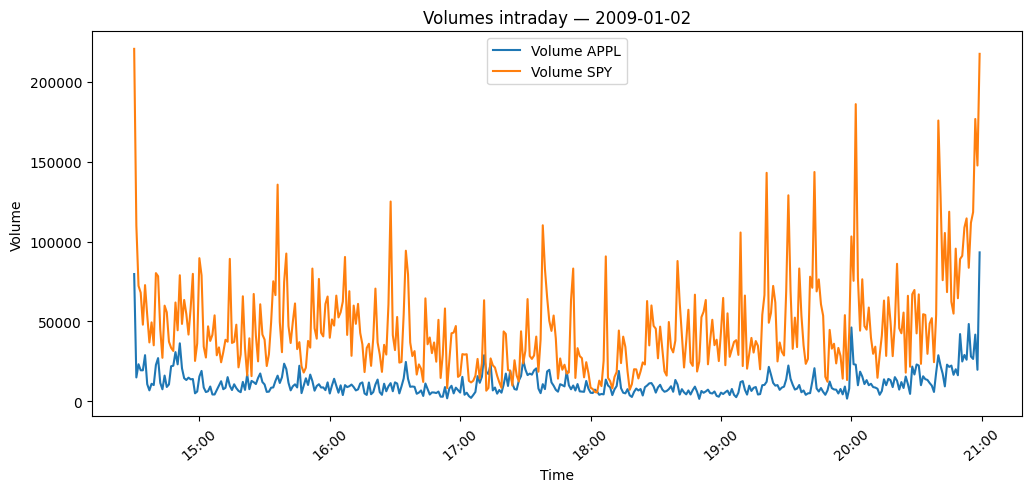

In [34]:
day = df_merged["datetime"][0].date()
df_day = df_merged.filter(pl.col("datetime").dt.date() == day)

plt.figure(figsize=(12,5))

plt.plot(df_day["datetime"], df_day["volume_APPL"], label="Volume APPL")
plt.plot(df_day["datetime"], df_day["volume_SPY"], label="Volume SPY")

plt.title(f"Volumes intraday — {day}")
plt.xlabel("Time")
plt.ylabel("Volume")

plt.legend()

plt.gca().xaxis.set_major_formatter(mdates.DateFormatter("%H:%M"))
plt.xticks(rotation=40)


plt.show()

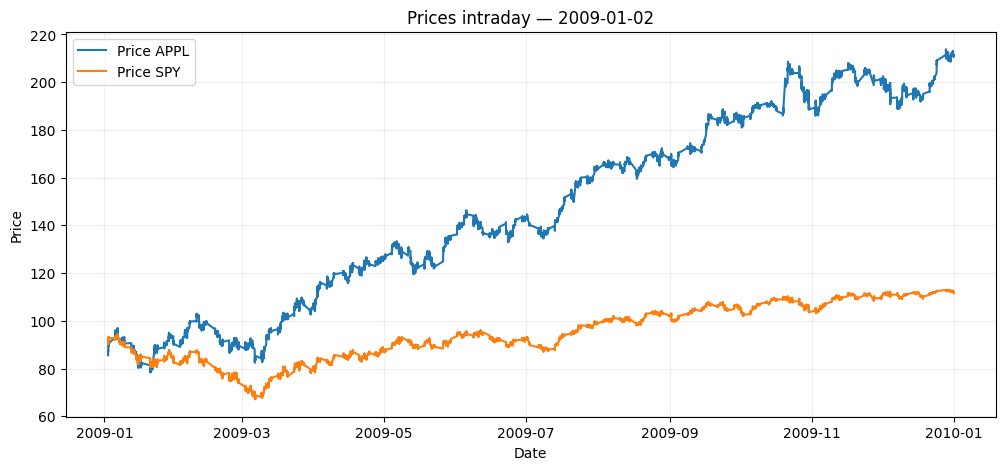

In [35]:
plt.figure(figsize=(12,5))

plt.plot(df_merged["datetime"], df_merged["price_APPL"], label="Price APPL")
plt.plot(df_merged["datetime"], df_merged["price_SPY"], label="Price SPY")

plt.title(f"Prices intraday — {day}")
plt.xlabel("Date")
plt.ylabel("Price")

plt.legend()
plt.grid(True, alpha=0.2)

plt.show()

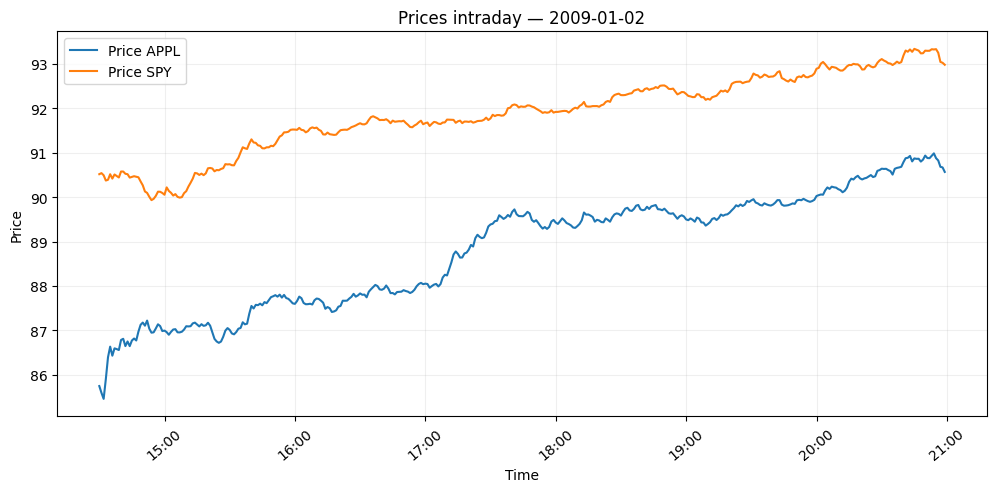

In [36]:
day = df_merged["datetime"][0].date()
df_day = df_merged.filter(pl.col("datetime").dt.date() == day)

plt.figure(figsize=(12,5))

plt.plot(df_day["datetime"], df_day["price_APPL"], label="Price APPL")
plt.plot(df_day["datetime"], df_day["price_SPY"], label="Price SPY")

plt.title(f"Prices intraday — {day}")
plt.xlabel("Time")
plt.ylabel("Price")

plt.legend()
plt.grid(True, alpha=0.2)

plt.gca().xaxis.set_major_formatter(mdates.DateFormatter("%H:%M"))
plt.xticks(rotation=40)

plt.show()

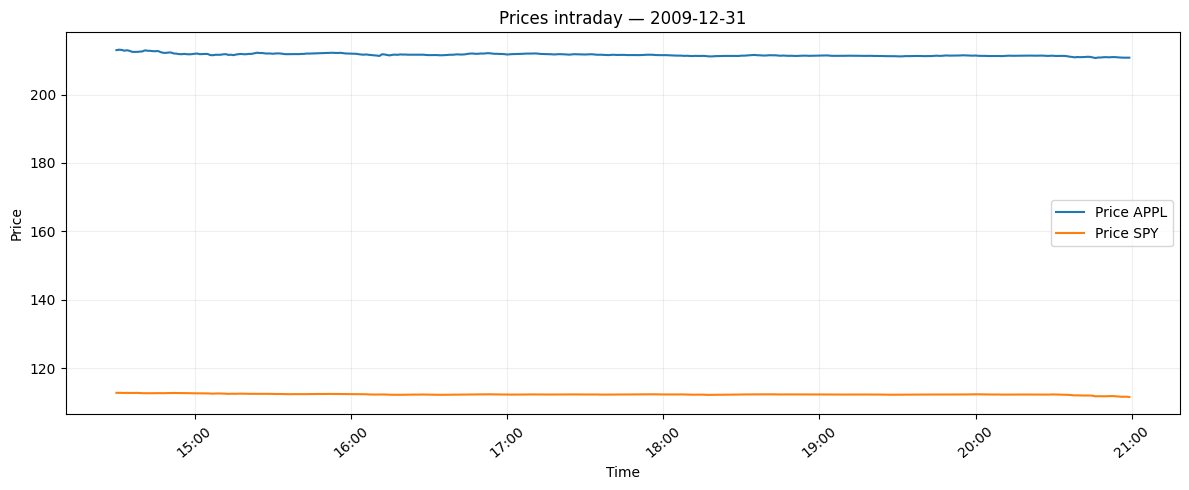

In [37]:
last_day = df_merged["datetime"][-1].date()

df_last = df_merged.filter(
    pl.col("datetime").dt.date() == last_day
)

plt.figure(figsize=(12,5))

plt.plot(df_last["datetime"], df_last["price_APPL"], label="Price APPL")
plt.plot(df_last["datetime"], df_last["price_SPY"], label="Price SPY")

plt.title(f"Prices intraday — {last_day}")
plt.xlabel("Time")
plt.ylabel("Price")

plt.legend()
plt.grid(True, alpha=0.2)

plt.gca().xaxis.set_major_formatter(mdates.DateFormatter("%H:%M"))
plt.xticks(rotation=40)

plt.tight_layout()
plt.show()

## return


In [38]:
df_returns = (
    df_merged
    .with_columns([
        (pl.col("price_APPL").log() - pl.col("price_APPL").log().shift(1)).alias("ret_APPL"),
        (pl.col("price_SPY").log() - pl.col("price_SPY").log().shift(1)).alias("ret_SPY"),
    ])
    .drop_nulls(subset=["ret_APPL", "ret_SPY"])  # supprime la première ligne
)

In [39]:
print(df_returns.head())

shape: (5, 7)
┌──────────────────┬────────────┬──────────────┬───────────┬───────────────┬───────────┬───────────┐
│ datetime         ┆ price_APPL ┆ volume_APPL  ┆ price_SPY ┆ volume_SPY    ┆ ret_APPL  ┆ ret_SPY   │
│ ---              ┆ ---        ┆ ---          ┆ ---       ┆ ---           ┆ ---       ┆ ---       │
│ datetime[μs, Ame ┆ f64        ┆ f64          ┆ f64       ┆ f64           ┆ f64       ┆ f64       │
│ rica/New_York]   ┆            ┆              ┆           ┆               ┆           ┆           │
╞══════════════════╪════════════╪══════════════╪═══════════╪═══════════════╪═══════════╪═══════════╡
│ 2009-01-02       ┆ 85.5945    ┆ 14969.909524 ┆ 90.541658 ┆ 110023.898034 ┆ -0.001791 ┆ 0.000264  │
│ 09:31:00 EST     ┆            ┆              ┆           ┆               ┆           ┆           │
│ 2009-01-02       ┆ 85.459586  ┆ 23222.12381  ┆ 90.493477 ┆ 72292.177567  ┆ -0.001577 ┆ -0.000532 │
│ 09:32:00 EST     ┆            ┆              ┆           ┆               ┆ 

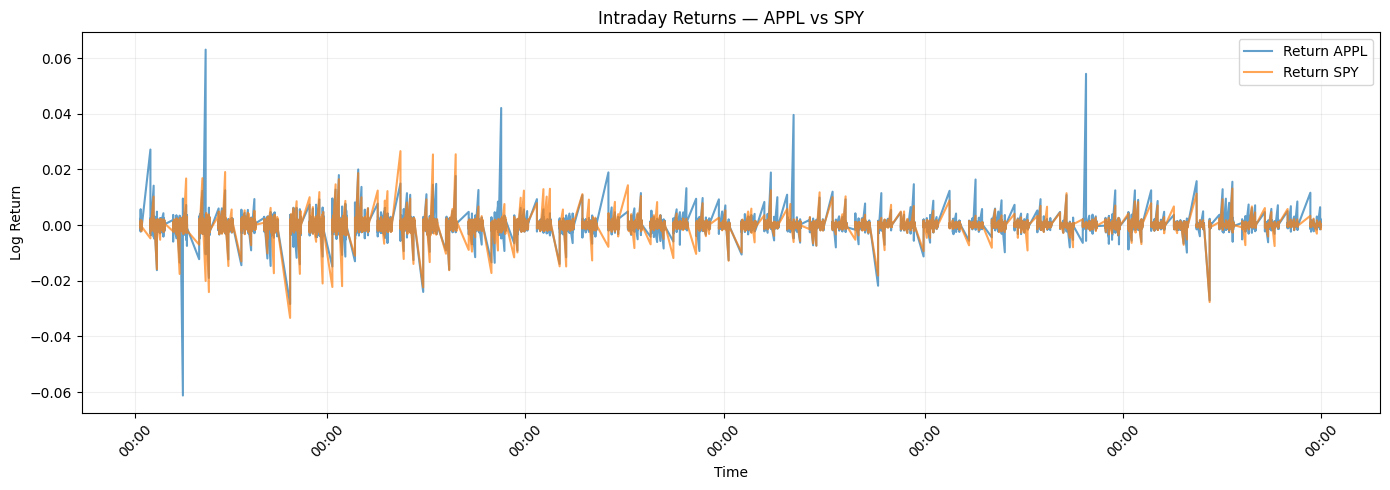

In [40]:
plt.figure(figsize=(14,5))
plt.plot(df_returns["datetime"], df_returns["ret_APPL"], label="Return APPL", alpha=0.7)
plt.plot(df_returns["datetime"], df_returns["ret_SPY"], label="Return SPY", alpha=0.7)

plt.title("Intraday Returns — APPL vs SPY")
plt.xlabel("Time")
plt.ylabel("Log Return")
plt.legend()
plt.grid(alpha=0.2)

plt.gca().xaxis.set_major_formatter(mdates.DateFormatter("%H:%M"))
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

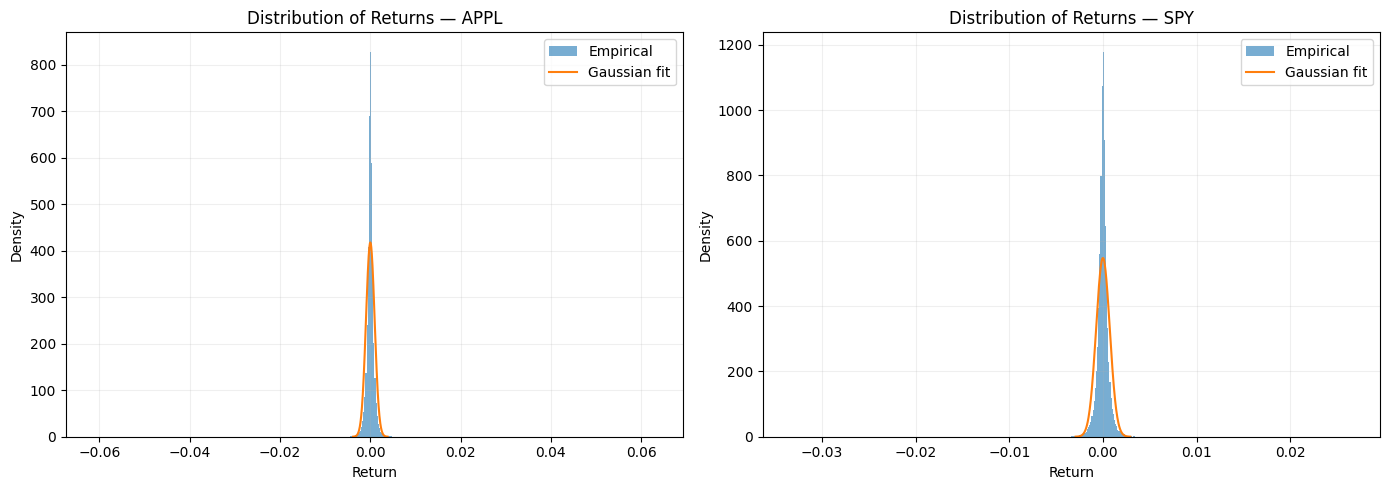

In [41]:
fig, ax = plt.subplots(1, 2, figsize=(14,5))

for i, (data, name) in enumerate([(df_returns["ret_APPL"].to_numpy(), "APPL"),(df_returns["ret_SPY"].to_numpy(), "SPY")]):
    mu, sigma = np.mean(data), np.std(data)

    ax[i].hist(data, bins=500, density=True, alpha=0.6, label="Empirical")
    
    x = np.linspace(mu - 4*sigma, mu + 4*sigma, 200)
    ax[i].plot(x, norm.pdf(x, mu, sigma), label="Gaussian fit")

    ax[i].set_title(f"Distribution of Returns — {name}")
    ax[i].set_xlabel("Return")
    ax[i].set_ylabel("Density")
    ax[i].legend()
    ax[i].grid(alpha=0.2)

plt.tight_layout()
plt.show()

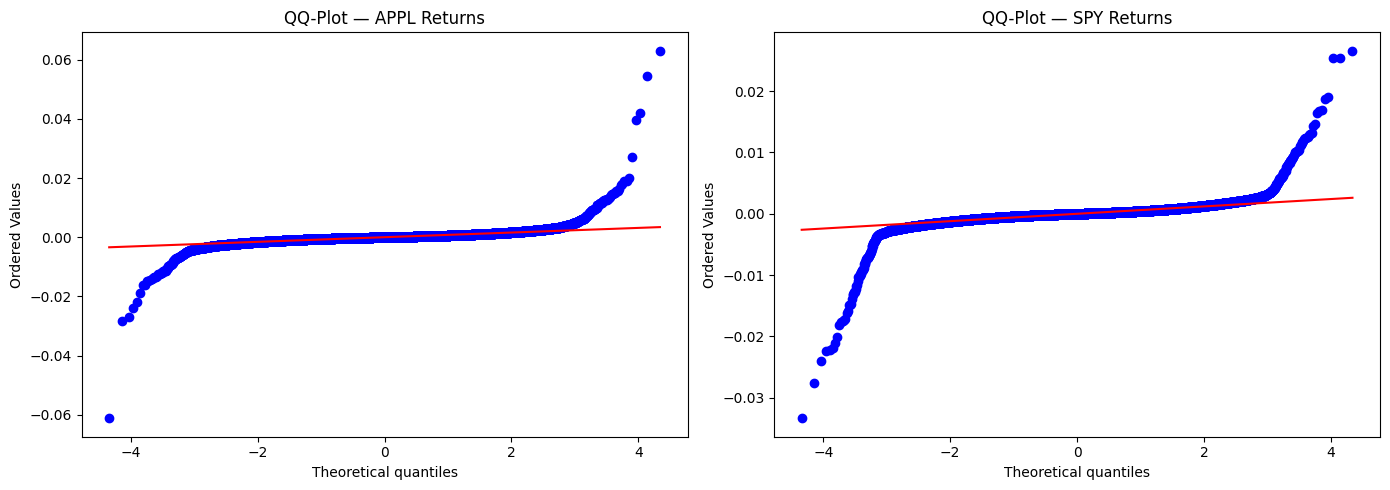

In [42]:
fig, ax = plt.subplots(1, 2, figsize=(14,5))
stats.probplot(df_returns["ret_APPL"], dist="norm", plot=ax[0])
ax[0].set_title("QQ-Plot — APPL Returns")
stats.probplot(df_returns["ret_SPY"], dist="norm", plot=ax[1])
ax[1].set_title("QQ-Plot — SPY Returns")
plt.tight_layout()
plt.show()

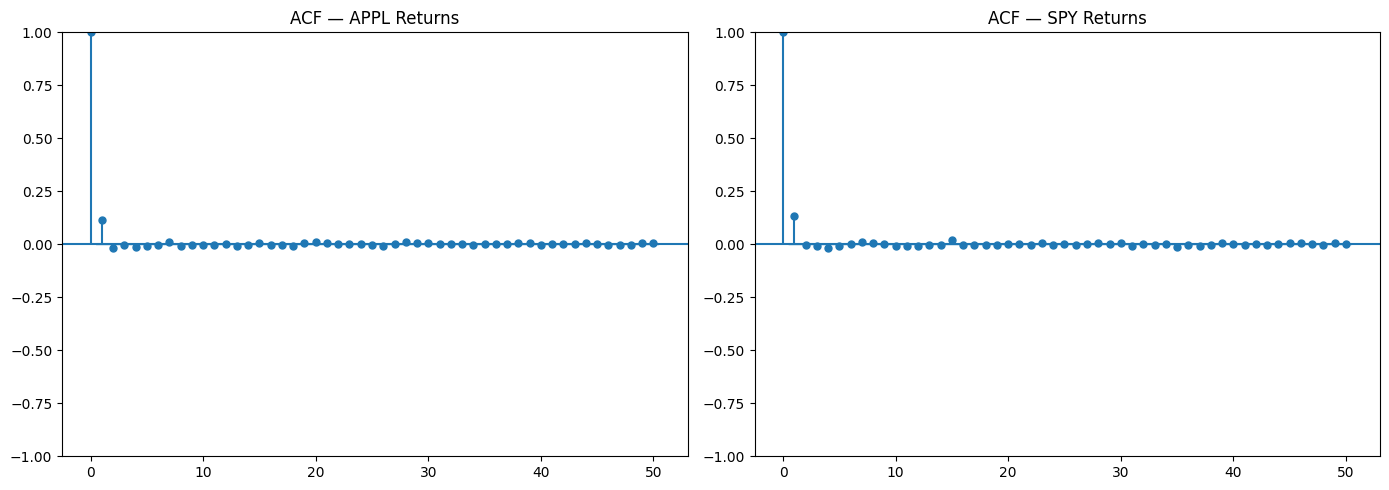

In [43]:
from statsmodels.graphics.tsaplots import plot_acf

fig, ax = plt.subplots(1, 2, figsize=(14,5))

plot_acf(df_returns["ret_APPL"], ax=ax[0], lags=50)
ax[0].set_title("ACF — APPL Returns")

plot_acf(df_returns["ret_SPY"], ax=ax[1], lags=50)
ax[1].set_title("ACF — SPY Returns")

plt.tight_layout()
plt.show()

## Cross Corellation (with and witout lag)

In [44]:
def cross_corr_at_lag(ret_appl, ret_spy, lag):
    """
    Compute correlation between ret_APPL(t+lag) and ret_SPY(t)
    lag > 0  -> test if SPY leads APPL
    lag < 0  -> test if APPL leads SPY
    """
    rA = ret_appl.to_numpy()
    rS = ret_spy.to_numpy()

    if lag > 0:
        return np.corrcoef(rA[lag:], rS[:-lag])[0, 1]
    elif lag < 0:
        lag = -lag
        return np.corrcoef(rA[:-lag], rS[lag:])[0, 1]
    else:
        return np.corrcoef(rA, rS)[0, 1]

In [45]:
lags = range(-10, 11)  # -10 à +10
cc_values = [cross_corr_at_lag(df_returns["ret_APPL"], df_returns["ret_SPY"], lag) for lag in lags]

In [46]:
cc_table = pd.DataFrame({
    "lag": list(lags),
    "cross_corr": cc_values
})

print(cc_table)

    lag  cross_corr
0   -10    0.000556
1    -9    0.002690
2    -8    0.000082
3    -7    0.006252
4    -6    0.001698
5    -5   -0.000064
6    -4   -0.007631
7    -3    0.002238
8    -2    0.005667
9    -1    0.099105
10    0    0.603380
11    1    0.063345
12    2   -0.020168
13    3   -0.010194
14    4   -0.016297
15    5   -0.011084
16    6   -0.005924
17    7    0.008351
18    8    0.005545
19    9   -0.005115
20   10   -0.002982


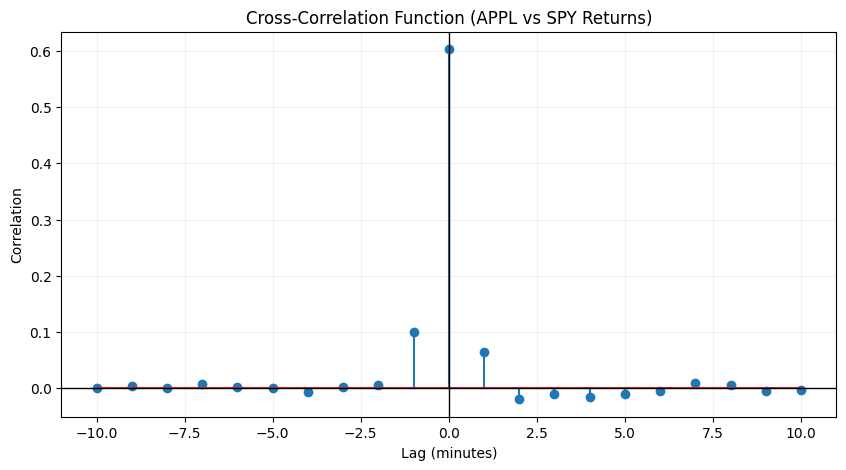

In [47]:
plt.figure(figsize=(10,5))
plt.stem(lags, cc_values)

plt.axhline(0, color='black', linewidth=1)
plt.axvline(0, color='black', linewidth=1)

plt.title("Cross-Correlation Function (APPL vs SPY Returns)")
plt.xlabel("Lag (minutes)")
plt.ylabel("Correlation")

plt.grid(alpha=0.2)
plt.show()

## Not much things to say in minute -> let's analyse it in secondes 

In [48]:
def bucket_1sec(df: pl.DataFrame) -> pl.DataFrame:
    return (
        df
        .group_by_dynamic(
            "datetime",
            every="1s",     # bucket de 1 seconde
            period="1s",
            closed="left",
            label="left",
        )
        .agg([
            pl.col("price").mean().alias("price"),
            pl.col("volume").sum().alias("volume"),
        ])
        .sort("datetime")
    )

In [49]:
df1_sec = bucket_1sec(df)
df2_sec = bucket_1sec(df1)

df1_sec = df1_sec.rename({
    "price": "price_APPL",
    "volume": "volume_APPL",
})

In [50]:
df_merged_sec = (
    df1_sec
    .join(df2_sec, on="datetime", how="inner")
    .rename({
        "price": "price_SPY",
        "volume": "volume_SPY",
    })
    .select([
        "datetime",
        "price_APPL",
        "volume_APPL",
        "price_SPY",
        "volume_SPY",
    ])
)

In [51]:
df_returns_sec = (
    df_merged_sec.with_columns([(pl.col("price_APPL").log() - pl.col("price_APPL").log().shift(1)).alias("ret_APPL"),(pl.col("price_SPY").log()  - pl.col("price_SPY").log().shift(1)).alias("ret_SPY"),]).drop_nulls(subset=["ret_APPL", "ret_SPY"])
)

In [52]:
print(df_returns_sec.head())

shape: (5, 7)
┌────────────────────┬────────────┬─────────────┬───────────┬──────────────┬───────────┬───────────┐
│ datetime           ┆ price_APPL ┆ volume_APPL ┆ price_SPY ┆ volume_SPY   ┆ ret_APPL  ┆ ret_SPY   │
│ ---                ┆ ---        ┆ ---         ┆ ---       ┆ ---          ┆ ---       ┆ ---       │
│ datetime[μs,       ┆ f64        ┆ f64         ┆ f64       ┆ f64          ┆ f64       ┆ f64       │
│ America/New_York]  ┆            ┆             ┆           ┆              ┆           ┆           │
╞════════════════════╪════════════╪═════════════╪═══════════╪══════════════╪═══════════╪═══════════╡
│ 2009-01-02         ┆ 85.553333  ┆ 166.666667  ┆ 90.5      ┆ 3634.0       ┆ -0.000526 ┆ 0.000597  │
│ 09:30:02 EST       ┆            ┆             ┆           ┆              ┆           ┆           │
│ 2009-01-02         ┆ 85.5825    ┆ 694.5       ┆ 90.444559 ┆ 23148.064866 ┆ 0.000341  ┆ -0.000613 │
│ 09:30:03 EST       ┆            ┆             ┆           ┆              ┆ 

In [53]:
def cross_corr_at_lag(ret_appl, ret_spy, lag_sec: int) -> float:
    """
    Corr( ret_APPL(t + lag), ret_SPY(t) )

    lag_sec > 0  -> SPY lead APPL
    lag_sec < 0  -> APPL lead SPY
    """
    rA = ret_appl.to_numpy()
    rS = ret_spy.to_numpy()

    if lag_sec > 0:
        return np.corrcoef(rA[lag_sec:], rS[:-lag_sec])[0, 1]
    elif lag_sec < 0:
        lag = -lag_sec
        return np.corrcoef(rA[:-lag], rS[lag:])[0, 1]
    else:
        return np.corrcoef(rA, rS)[0, 1]

In [54]:
lags = range(-60, 61)
cc_values = [
    cross_corr_at_lag(df_returns_sec["ret_APPL"], df_returns_sec["ret_SPY"], lag)
    for lag in lags
]

In [55]:
cc_table = pd.DataFrame({"lag_sec": list(lags), "corr": cc_values})
cc_table_sorted = cc_table.sort_values("corr", ascending=False)

print(cc_table_sorted.head(10))

    lag_sec      corr
60        0  0.474816
59       -1  0.135003
61        1  0.094523
58       -2  0.020273
62        2  0.013612
57       -3  0.006576
63        3  0.004341
45      -15  0.002200
56       -4  0.002112
46      -14  0.001652


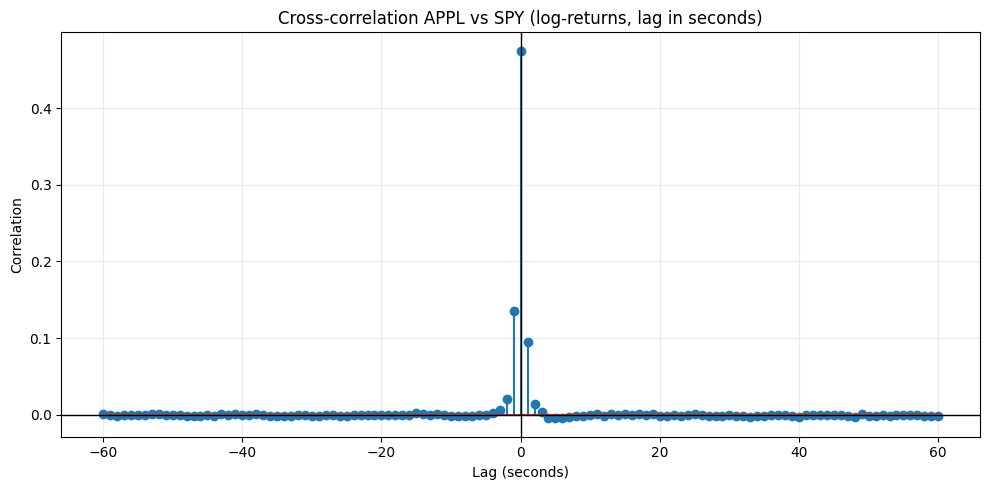

In [56]:
plt.figure(figsize=(10,5))
plt.stem(lags, cc_values)

plt.axhline(0, color="black", linewidth=1)
plt.axvline(0, color="black", linewidth=1)

plt.title("Cross-correlation APPL vs SPY (log-returns, lag in seconds)")
plt.xlabel("Lag (seconds)")
plt.ylabel("Correlation")

plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()

## Only the first few secondes have non neglegeable correlation

In [ ]:
df_returns = df_returns.with_columns(
    (pl.col("ret_APPL") - pl.col("ret_SPY")).alias("diff_ret")
) # TODO APPL -> AAPL

In [69]:
lags = range(-10, 11)  # -10 à +10
corr_diff_ret_vol_SPY_values = [cross_corr_at_lag(df_returns["diff_ret"], df_returns["volume_SPY"], lag) for lag in lags]
corr_diff_ret_vol_AAPL_values = [cross_corr_at_lag(df_returns["diff_ret"], df_returns["volume_APPL"], lag) for lag in lags]
corr_diff_ret_vol_tot_values = [cross_corr_at_lag(df_returns["diff_ret"], df_returns["volume_SPY"] + df_returns["volume_APPL"], lag) for lag in lags]

In [70]:
corr_diff_ret_vol_SPY_table = pd.DataFrame({
    "lag": list(lags),
    "corelation between the difference in returns and volatility of SPY": corr_diff_ret_vol_SPY_values
})

print(corr_diff_ret_vol_SPY_table)

    lag  corelation between the difference in returns and volatility of SPY
0   -10                                           0.004777                 
1    -9                                           0.009133                 
2    -8                                           0.013313                 
3    -7                                           0.008439                 
4    -6                                           0.009668                 
5    -5                                           0.007774                 
6    -4                                           0.008318                 
7    -3                                           0.003078                 
8    -2                                           0.004103                 
9    -1                                           0.004804                 
10    0                                           0.007593                 
11    1                                           0.014897                 
12    2     

In [71]:
corr_diff_ret_vol_AAPL_table = pd.DataFrame({
    "lag": list(lags),
    "corelation between the difference in returns and volatility of AAPL": corr_diff_ret_vol_AAPL_values
})

print(corr_diff_ret_vol_AAPL_table)

    lag  corelation between the difference in returns and volatility of AAPL
0   -10                                           0.006031                  
1    -9                                           0.011172                  
2    -8                                           0.010569                  
3    -7                                           0.008267                  
4    -6                                           0.009295                  
5    -5                                           0.005479                  
6    -4                                           0.005602                  
7    -3                                           0.005792                  
8    -2                                           0.005658                  
9    -1                                           0.009770                  
10    0                                           0.074485                  
11    1                                           0.017914                  

In [72]:
corr_diff_ret_vol_tot_table = pd.DataFrame({
    "lag": list(lags),
    "corelation between the difference in returns and volatility of SPY": corr_diff_ret_vol_tot_values
})

print(corr_diff_ret_vol_tot_table)

    lag  corelation between the difference in returns and volatility of SPY
0   -10                                           0.006667                 
1    -9                                           0.012561                 
2    -8                                           0.015374                 
3    -7                                           0.010551                 
4    -6                                           0.011996                 
5    -5                                           0.008622                 
6    -4                                           0.009091                 
7    -3                                           0.005275                 
8    -2                                           0.005971                 
9    -1                                           0.008608                 
10    0                                           0.043933                 
11    1                                           0.020331                 
12    2     

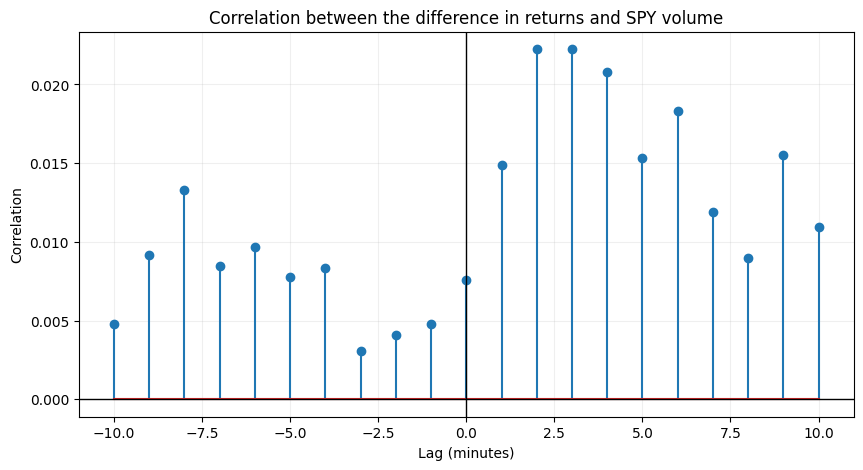

In [80]:
def corr_at_lag(lags, corr, title):
    plt.figure(figsize=(10,5))
    plt.stem(lags, corr)

    plt.axhline(0, color='black', linewidth=1)
    plt.axvline(0, color='black', linewidth=1)

    plt.title(title)
    plt.xlabel("Lag (minutes)")
    plt.ylabel("Correlation")  

    plt.grid(alpha=0.2)
    plt.show()

corr_at_lag(lags, corr_diff_ret_vol_SPY_values, "Correlation between the difference in returns and SPY volume")

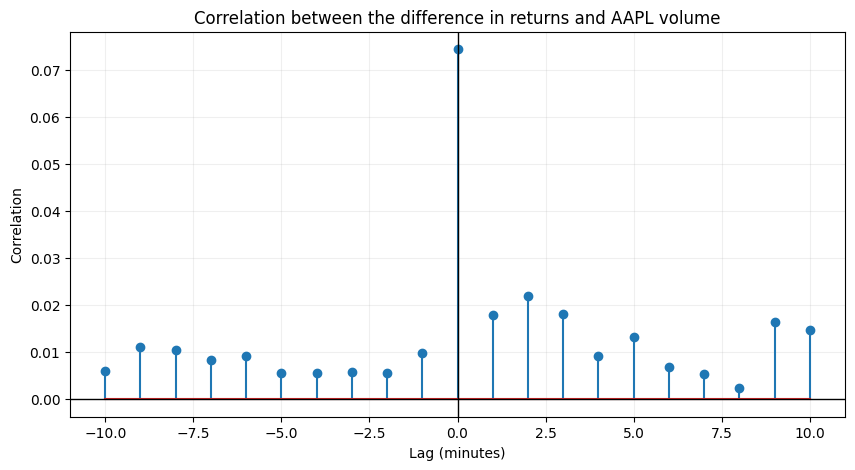

In [78]:
corr_at_lag(lags, corr_diff_ret_vol_AAPL_values, "Correlation between the difference in returns and AAPL volume")

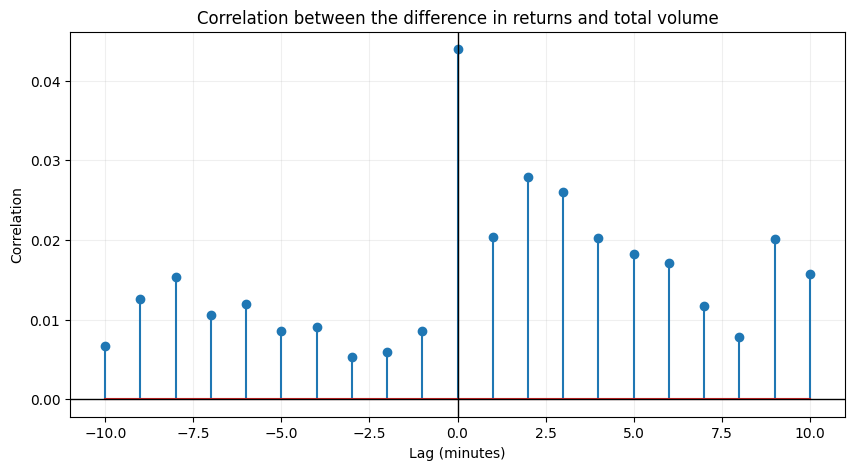

In [79]:
corr_at_lag(lags, corr_diff_ret_vol_tot_values, "Correlation between the difference in returns and total volume")

In [81]:
df_returns_sec = df_returns_sec.with_columns(
    (pl.col("ret_APPL") - pl.col("ret_SPY")).alias("diff_ret")
) # TODO APPL -> AAPL

In [83]:
lags_sec = range(-60, 61)  # -60 à +60
corr_diff_ret_vol_SPY_values_sec = [cross_corr_at_lag(df_returns_sec["diff_ret"], df_returns_sec["volume_SPY"], lag) for lag in lags_sec]
corr_diff_ret_vol_AAPL_values_sec = [cross_corr_at_lag(df_returns_sec["diff_ret"], df_returns_sec["volume_APPL"], lag) for lag in lags_sec]
corr_diff_ret_vol_tot_values_sec = [cross_corr_at_lag(df_returns_sec["diff_ret"], df_returns_sec["volume_SPY"] + df_returns_sec["volume_APPL"], lag) for lag in lags_sec]

In [85]:
corr_diff_ret_vol_SPY_table_sec = pd.DataFrame({
    "lag": list(lags_sec),
    "corelation between the difference in returns and volatility of SPY": corr_diff_ret_vol_SPY_values_sec
})

print(corr_diff_ret_vol_SPY_table_sec)

     lag  corelation between the difference in returns and volatility of SPY
0    -60                                           0.000790                 
1    -59                                          -0.000242                 
2    -58                                           0.000706                 
3    -57                                           0.000177                 
4    -56                                          -0.001864                 
..   ...                                                ...                 
116   56                                           0.000717                 
117   57                                           0.000028                 
118   58                                           0.001342                 
119   59                                           0.001427                 
120   60                                           0.000546                 

[121 rows x 2 columns]


In [87]:
corr_diff_ret_vol_AAPL_table_sec = pd.DataFrame({
    "lag": list(lags_sec),
    "corelation between the difference in returns and volatility of AAPL": corr_diff_ret_vol_AAPL_values_sec
})

print(corr_diff_ret_vol_AAPL_table_sec)

     lag  corelation between the difference in returns and volatility of AAPL
0    -60                                          -0.000100                  
1    -59                                           0.000589                  
2    -58                                          -0.000349                  
3    -57                                          -0.000103                  
4    -56                                           0.000059                  
..   ...                                                ...                  
116   56                                           0.000449                  
117   57                                          -0.000987                  
118   58                                          -0.000539                  
119   59                                           0.001179                  
120   60                                           0.001076                  

[121 rows x 2 columns]


In [88]:
corr_diff_ret_vol_tot_table_sec = pd.DataFrame({
    "lag": list(lags_sec),
    "corelation between the difference in returns and volatility of SPY": corr_diff_ret_vol_tot_values_sec
})

print(corr_diff_ret_vol_tot_table_sec)

     lag  corelation between the difference in returns and volatility of SPY
0    -60                                           0.000272                 
1    -59                                           0.000408                 
2    -58                                           0.000015                 
3    -57                                          -0.000010                 
4    -56                                          -0.000797                 
..   ...                                                ...                 
116   56                                           0.000722                 
117   57                                          -0.000856                 
118   58                                           0.000137                 
119   59                                           0.001688                 
120   60                                           0.001196                 

[121 rows x 2 columns]


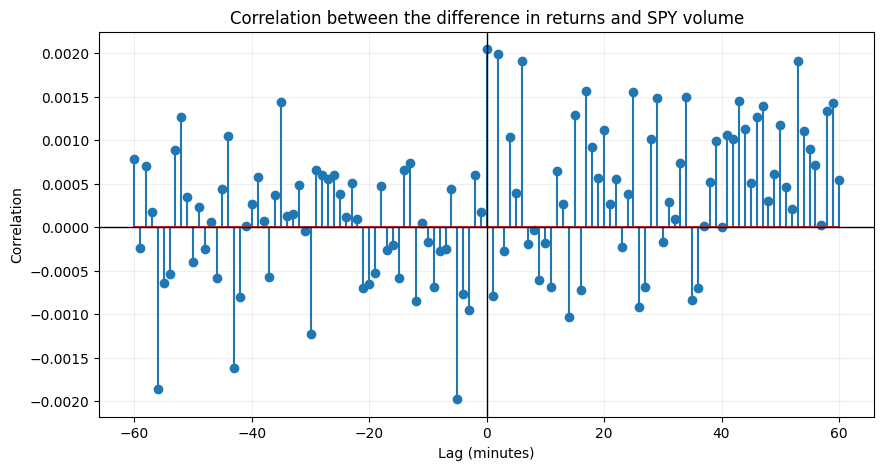

In [92]:
corr_at_lag(lags_sec, corr_diff_ret_vol_SPY_values_sec, "Correlation between the difference in returns and SPY volume")

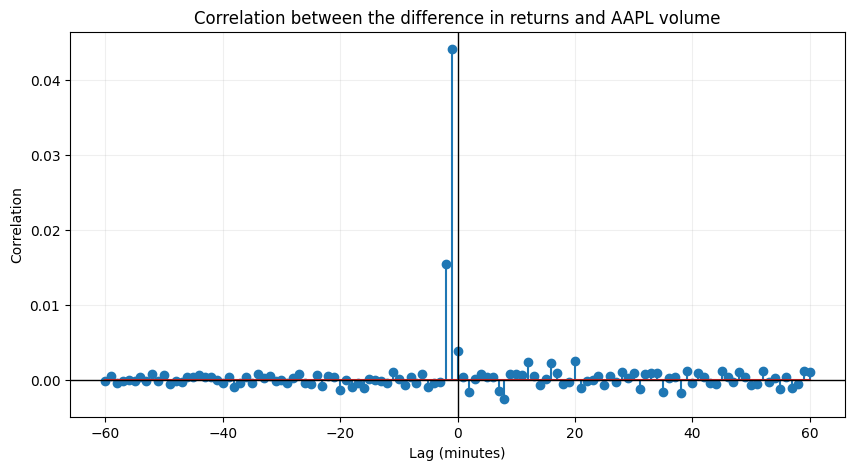

In [93]:
corr_at_lag(lags_sec, corr_diff_ret_vol_AAPL_values_sec, "Correlation between the difference in returns and AAPL volume")

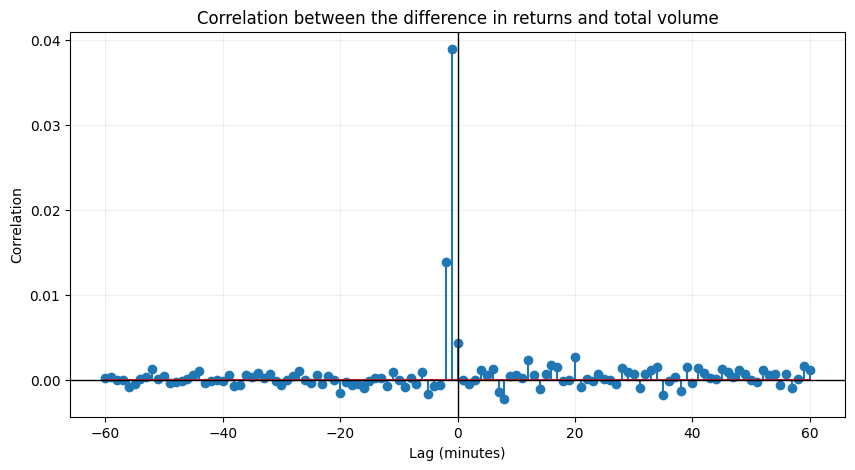

In [94]:
corr_at_lag(lags_sec, corr_diff_ret_vol_tot_values_sec, "Correlation between the difference in returns and total volume")

In [99]:
df_returns_sec = df_returns_sec.with_columns(
    pl.col("diff_ret")
    .rolling_std(window_size=300, min_samples=60)
    .alias("spread_std_5min")
)

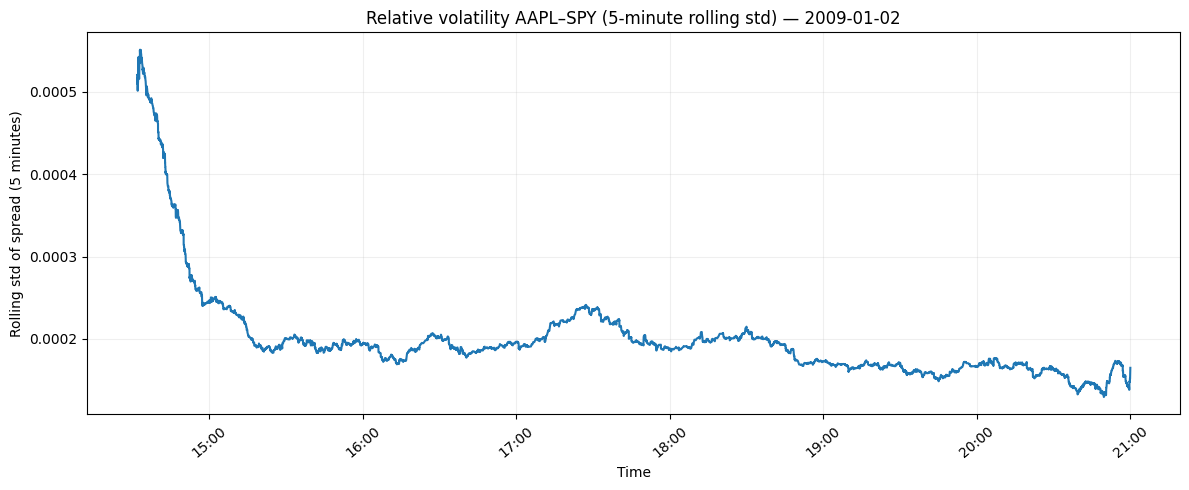

In [103]:
day = df_returns_sec["datetime"][0].date()
df_day = df_returns_sec.filter(pl.col("datetime").dt.date() == day)

plt.figure(figsize=(12,5))
plt.plot(df_day["datetime"], df_day["spread_std_5min"])
plt.xlabel("Time")
plt.ylabel("Rolling std of spread (5 minutes)")
plt.title(f"Relative volatility AAPL–SPY (5-minute rolling std) — {day}")
plt.grid(True, alpha=0.2)
ax = plt.gca()
ax.xaxis.set_major_locator(mdates.HourLocator(interval=1))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%H:%M"))
plt.xticks(rotation=40)
plt.tight_layout()
plt.show()